# DSA210 — Tech Job Market Salary Analysis
**Author:** cansatir  
**Datasets:** lukebarousse/data_jobs · BLS OEWS

## 0. Setup & Imports

In [1]:
from pathlib import Path
import ast, json, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Pin CWD to project root (works whether run interactively or via nbconvert)
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
os.chdir(PROJECT_ROOT)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

DATA_RAW       = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'figures'
RESULTS        = PROJECT_ROOT / 'results'

for d in (DATA_PROCESSED, FIGURES, RESULTS):
    d.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')

Project root: /app


## 1. Load & Inspect Raw Datasets

In [2]:
# ── Jobs dataset ──────────────────────────────────────────────
df_jobs = pd.read_parquet(DATA_RAW / 'jobs_raw.parquet')
print(f'Shape: {df_jobs.shape}')
print(f'\nDtypes:\n{df_jobs.dtypes}')
print(f'\nMissing values (top 10):\n{df_jobs.isnull().sum().sort_values(ascending=False).head(10)}')
df_jobs.head()

Shape: (785741, 17)

Dtypes:
job_title_short           object
job_title                 object
job_location              object
job_via                   object
job_schedule_type         object
job_work_from_home          bool
search_location           object
job_posted_date           object
job_no_degree_mention       bool
job_health_insurance        bool
job_country               object
salary_rate               object
salary_year_avg          float64
salary_hour_avg          float64
company_name              object
job_skills                object
job_type_skills           object
dtype: object

Missing values (top 10):
salary_hour_avg      775079
salary_year_avg      763738
salary_rate          752674
job_type_skills      117037
job_skills           117037
job_schedule_type     12667
job_location           1045
job_country              49
company_name             18
job_via                   8
dtype: int64


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [3]:
# ── OEWS enrichment dataset ───────────────────────────────────
OEWS_COLS = ['OCC_CODE', 'OCC_TITLE', 'A_MEAN', 'A_MEDIAN',
             'A_PCT10', 'A_PCT25', 'A_PCT75', 'A_PCT90']
oews_raw = pd.read_excel(DATA_RAW / 'oews_national.xlsx',
                         header=0, dtype={'OCC_CODE': str})
print(f'Shape: {oews_raw.shape}')
print(f'\nDtypes:\n{oews_raw.dtypes}')
print(f'\nMissing values (key cols):\n{oews_raw[OEWS_COLS].isnull().sum()}')
oews_raw[OEWS_COLS].head()

Shape: (1403, 32)

Dtypes:
AREA              int64
AREA_TITLE       object
AREA_TYPE         int64
PRIM_STATE       object
NAICS             int64
NAICS_TITLE      object
I_GROUP          object
OWN_CODE          int64
OCC_CODE         object
OCC_TITLE        object
O_GROUP          object
TOT_EMP           int64
EMP_PRSE        float64
JOBS_1000       float64
LOC_QUOTIENT    float64
PCT_TOTAL       float64
PCT_RPT         float64
H_MEAN           object
A_MEAN           object
MEAN_PRSE       float64
H_PCT10          object
H_PCT25          object
H_MEDIAN         object
H_PCT75          object
H_PCT90          object
A_PCT10          object
A_PCT25          object
A_MEDIAN         object
A_PCT75          object
A_PCT90          object
ANNUAL           object
HOURLY           object
dtype: object

Missing values (key cols):
OCC_CODE     0
OCC_TITLE    0
A_MEAN       0
A_MEDIAN     0
A_PCT10      0
A_PCT25      0
A_PCT75      0
A_PCT90      0
dtype: int64


,OCC_CODE,OCC_TITLE,A_MEAN,A_MEDIAN,A_PCT10,A_PCT25,A_PCT75,A_PCT90
0,00-0000,All Occupations,67920,49500,29990,36730,78810,125720
1,11-0000,Management Occupations,141760,122090,57010,79900,171610,#
2,11-1000,Top Executives,139860,104990,47510,68800,168490,#
3,11-1010,Chief Executives,262930,206420,73710,126080,#,#
4,11-1011,Chief Executives,262930,206420,73710,126080,#,#


In [4]:
print(f'Section 1 complete — jobs: {df_jobs.shape}, oews: {oews_raw.shape}')

Section 1 complete — jobs: (785741, 17), oews: (1403, 32)


## 2. Data Cleaning & Preprocessing

In [5]:
# ── Drop rows with null salary_year_avg ───────────────────────
n_before = len(df_jobs)
df_clean = df_jobs.dropna(subset=['salary_year_avg']).copy()
n_dropped = n_before - len(df_clean)
print(f'Dropped {n_dropped:,} rows ({100 * n_dropped / n_before:.1f}%) with null salary_year_avg')

Dropped 763,738 rows (97.2%) with null salary_year_avg


In [6]:
# ── Remove salary outliers via 1.5× IQR ───────────────────────
q1, q3 = df_clean['salary_year_avg'].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_before_iqr = len(df_clean)
df_clean = df_clean[df_clean['salary_year_avg'].between(lo, hi)].copy()
n_removed = n_before_iqr - len(df_clean)
print(f'IQR bounds: [{lo:,.0f}, {hi:,.0f}]')
print(f'Removed {n_removed:,} outliers ({100 * n_removed / n_before_iqr:.1f}%)')
print(f'Remaining rows: {len(df_clean):,}')

IQR bounds: [0, 240,000]
Removed 416 outliers (1.9%)
Remaining rows: 21,587


In [7]:
# ── Parse job_posted_date to datetime ─────────────────────────
df_clean['job_posted_date'] = pd.to_datetime(df_clean['job_posted_date'])
print('Date range:', df_clean['job_posted_date'].min(),
      '→', df_clean['job_posted_date'].max())

Date range: 2023-01-01 00:02:56 → 2023-12-31 23:40:32


In [8]:
# ── Extract seniority from job_title ──────────────────────────
def extract_seniority(title: str) -> str:
    t = str(title).lower()
    if any(w in t for w in ('senior', 'lead', 'principal', 'sr.')):
        return 'Senior'
    if any(w in t for w in ('junior', 'jr.', 'jr ', 'entry')):
        return 'Junior'
    return 'Mid'

df_clean['seniority'] = df_clean['job_title'].apply(extract_seniority)
print('Seniority distribution:')
print(df_clean['seniority'].value_counts())

Seniority distribution:
seniority
Mid       14359
Senior     6762
Junior      466
Name: count, dtype: int64


In [9]:
# ── Parse job_skills string into Python list ──────────────────
def parse_skills(s) -> list:
    if pd.isna(s):
        return []
    try:
        return ast.literal_eval(s)
    except Exception:
        return []

df_clean['skills_list'] = df_clean['job_skills'].apply(parse_skills)
n_with_skills = (df_clean['skills_list'].apply(len) > 0).sum()
print(f'Rows with ≥1 skill: {n_with_skills:,}')

Rows with ≥1 skill: 19,815


In [10]:
# ── Save cleaned data ─────────────────────────────────────────
df_clean.to_parquet(DATA_PROCESSED / 'jobs_clean.parquet', index=False)
print(f'Section 2 complete — {len(df_clean):,} rows saved to jobs_clean.parquet')

Section 2 complete — 21,587 rows saved to jobs_clean.parquet


## 3. Enrich with BLS OEWS

In [11]:
# ── Reload cleaned data and OEWS ──────────────────────────────
df_clean = pd.read_parquet(DATA_PROCESSED / 'jobs_clean.parquet')
OEWS_COLS = ['OCC_CODE', 'OCC_TITLE', 'A_MEAN', 'A_MEDIAN',
             'A_PCT10', 'A_PCT25', 'A_PCT75', 'A_PCT90']
oews = pd.read_excel(DATA_RAW / 'oews_national.xlsx',
                     header=0, dtype={'OCC_CODE': str})
oews = oews[OEWS_COLS].drop_duplicates('OCC_CODE').copy()
for col in ['A_MEAN', 'A_MEDIAN', 'A_PCT10', 'A_PCT25', 'A_PCT75', 'A_PCT90']:
    oews[col] = pd.to_numeric(oews[col], errors='coerce')
print(f'OEWS rows after dedup: {len(oews)}')

OEWS rows after dedup: 1396


In [12]:
# ── Map job_title_short → BLS OCC_CODE ───────────────────────
OCC_MAP = {
    'Data Scientist':            '15-2051',
    'Data Engineer':             '15-1243',
    'Data Analyst':              '15-2031',
    'Software Engineer':         '15-1252',
    'Machine Learning Engineer': '15-2051',
    'Cloud Engineer':            '15-1299',
    'Business Analyst':          '13-1111',
    'Senior Data Scientist':     '15-2051',
    'Senior Data Engineer':      '15-1243',
    'Senior Data Analyst':       '15-2031',
}
df_clean = df_clean.copy()
df_clean['OCC_CODE'] = df_clean['job_title_short'].map(OCC_MAP)
mapped_pct = df_clean['OCC_CODE'].notna().mean() * 100
print(f'Title mapping coverage: {mapped_pct:.1f}% of rows')

Title mapping coverage: 100.0% of rows


In [13]:
# ── Merge and compute salary_gap ─────────────────────────────
df_enriched = df_clean.merge(oews, on='OCC_CODE', how='left')
merge_rate = df_enriched['A_MEAN'].notna().mean() * 100
df_enriched['salary_gap'] = df_enriched['salary_year_avg'] - df_enriched['A_MEAN']
gap_mean   = df_enriched['salary_gap'].mean()
gap_median = df_enriched['salary_gap'].median()
print(f'Merge success rate:                  {merge_rate:.1f}%')
print(f'Mean salary gap (advertised − BLS):   ${gap_mean:,.0f}')
print(f'Median salary gap (advertised − BLS): ${gap_median:,.0f}')

Merge success rate:                  100.0%
Mean salary gap (advertised − BLS):   $-2,086
Median salary gap (advertised − BLS): $-4,570


In [14]:
# ── Save enriched data ────────────────────────────────────────
df_enriched.to_parquet(DATA_PROCESSED / 'jobs_enriched.parquet', index=False)
print(f'Section 3 complete — {len(df_enriched):,} rows saved to jobs_enriched.parquet')

Section 3 complete — 21,587 rows saved to jobs_enriched.parquet


## 4. Exploratory Data Analysis

In [15]:
df = pd.read_parquet(DATA_PROCESSED / 'jobs_enriched.parquet')
print(f'Loaded {len(df):,} rows for EDA')

Loaded 21,587 rows for EDA


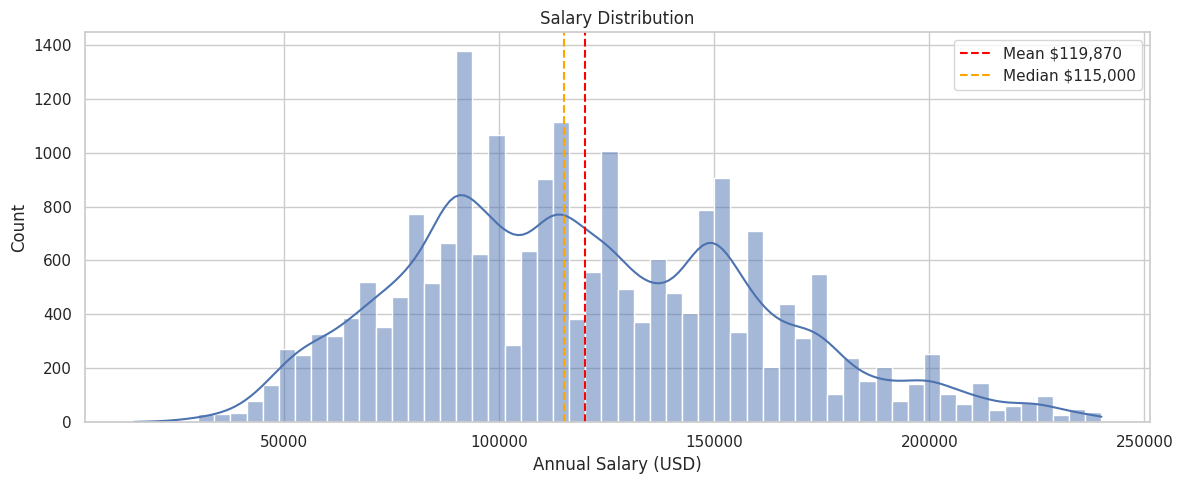

In [16]:
# fig1 — Salary distribution ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df['salary_year_avg'], bins=60, kde=True, ax=ax)
ax.axvline(df['salary_year_avg'].mean(),
           color='red', linestyle='--',
           label=f"Mean ${df['salary_year_avg'].mean():,.0f}")
ax.axvline(df['salary_year_avg'].median(),
           color='orange', linestyle='--',
           label=f"Median ${df['salary_year_avg'].median():,.0f}")
ax.set_title('Salary Distribution')
ax.set_xlabel('Annual Salary (USD)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'fig1_salary_distribution.png', dpi=120)
plt.show()

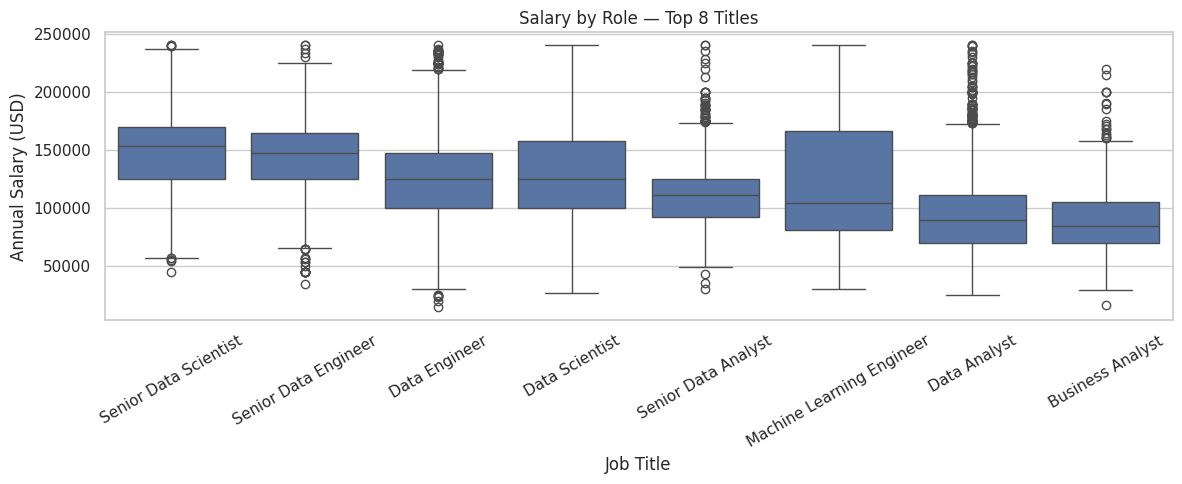

In [17]:
# fig2 — Salary by role (top 8) ────────────────────────────────
top_roles = df['job_title_short'].value_counts().head(8).index
df_top = df[df['job_title_short'].isin(top_roles)]
order = (df_top.groupby('job_title_short')['salary_year_avg']
               .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_top, x='job_title_short', y='salary_year_avg',
            order=order, ax=ax)
ax.set_title('Salary by Role — Top 8 Titles')
ax.set_xlabel('Job Title')
ax.set_ylabel('Annual Salary (USD)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES / 'fig2_salary_by_role.png', dpi=120)
plt.show()

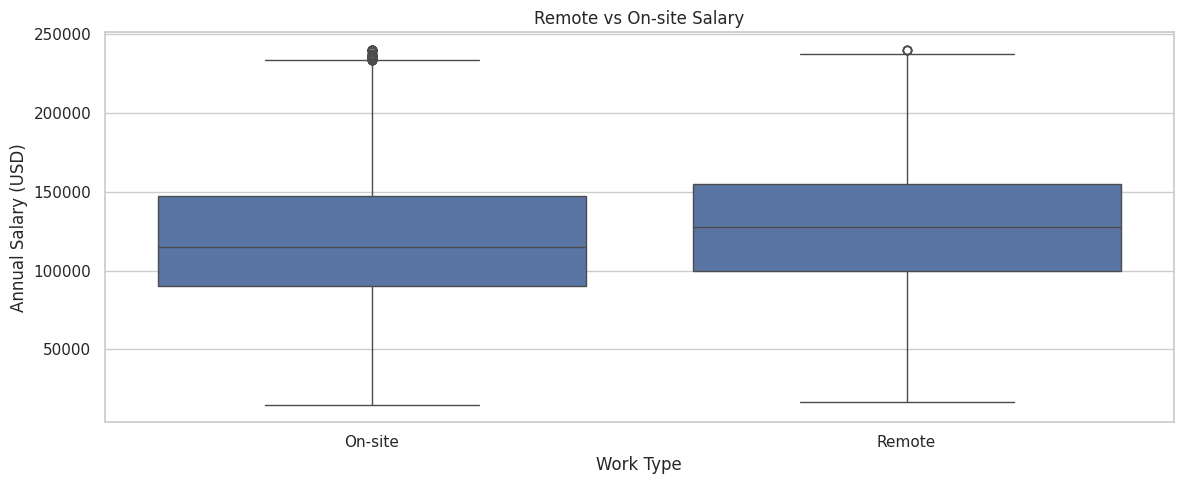

In [18]:
# fig3 — Remote vs on-site ─────────────────────────────────────
df_r = df.copy()
df_r['work_type'] = df_r['job_work_from_home'].map({True: 'Remote', False: 'On-site'})

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_r, x='work_type', y='salary_year_avg', ax=ax)
ax.set_title('Remote vs On-site Salary')
ax.set_xlabel('Work Type')
ax.set_ylabel('Annual Salary (USD)')
plt.tight_layout()
plt.savefig(FIGURES / 'fig3_remote_vs_onsite.png', dpi=120)
plt.show()

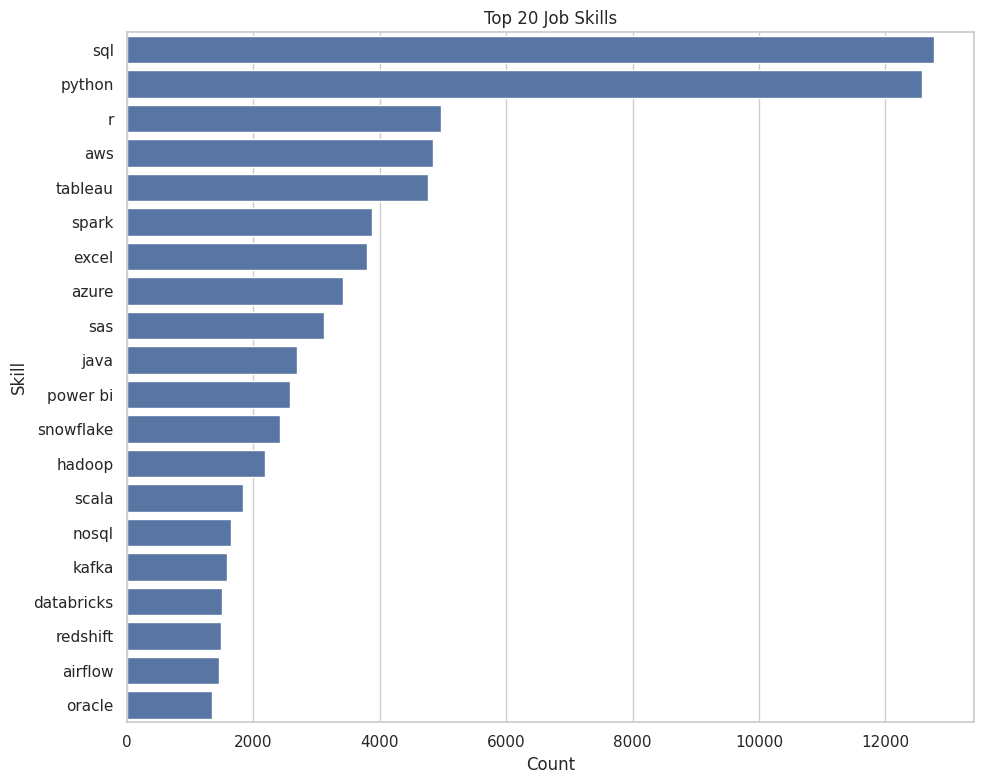

In [19]:
# fig4 — Top 20 skills ─────────────────────────────────────────
from collections import Counter
all_skills = [s for row in df['skills_list'] for s in row]
top20 = pd.DataFrame(Counter(all_skills).most_common(20),
                     columns=['skill', 'count'])

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top20, x='count', y='skill', ax=ax)
ax.set_title('Top 20 Job Skills')
ax.set_xlabel('Count')
ax.set_ylabel('Skill')
plt.tight_layout()
plt.savefig(FIGURES / 'fig4_top_skills.png', dpi=120)
plt.show()

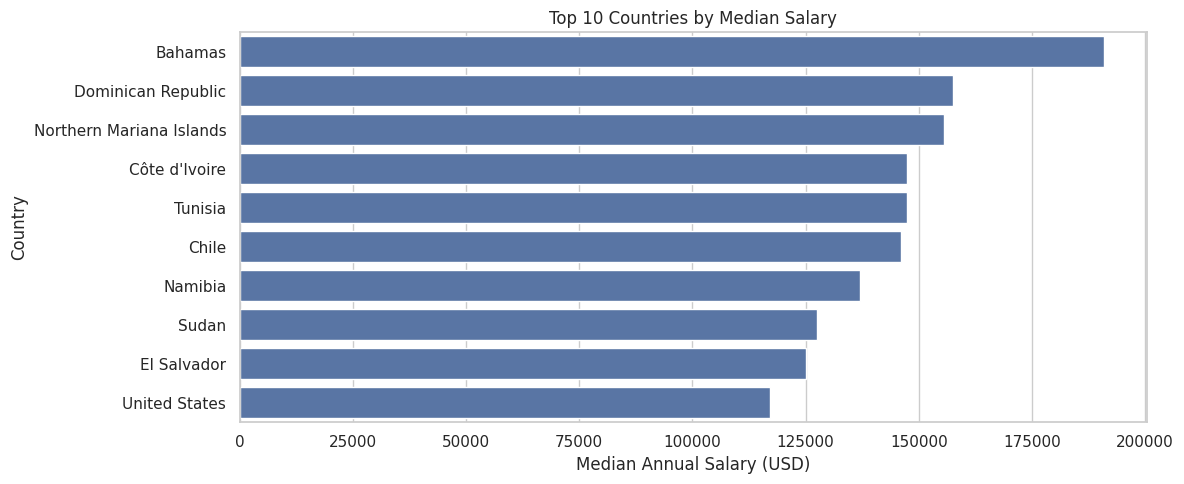

In [20]:
# fig5 — Top 10 countries by median salary ─────────────────────
top_countries = (df.groupby('job_country')['salary_year_avg']
                   .median().nlargest(10)
                   .reset_index(name='median_salary'))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top_countries, x='median_salary', y='job_country', ax=ax)
ax.set_title('Top 10 Countries by Median Salary')
ax.set_xlabel('Median Annual Salary (USD)')
ax.set_ylabel('Country')
plt.tight_layout()
plt.savefig(FIGURES / 'fig5_salary_by_country.png', dpi=120)
plt.show()

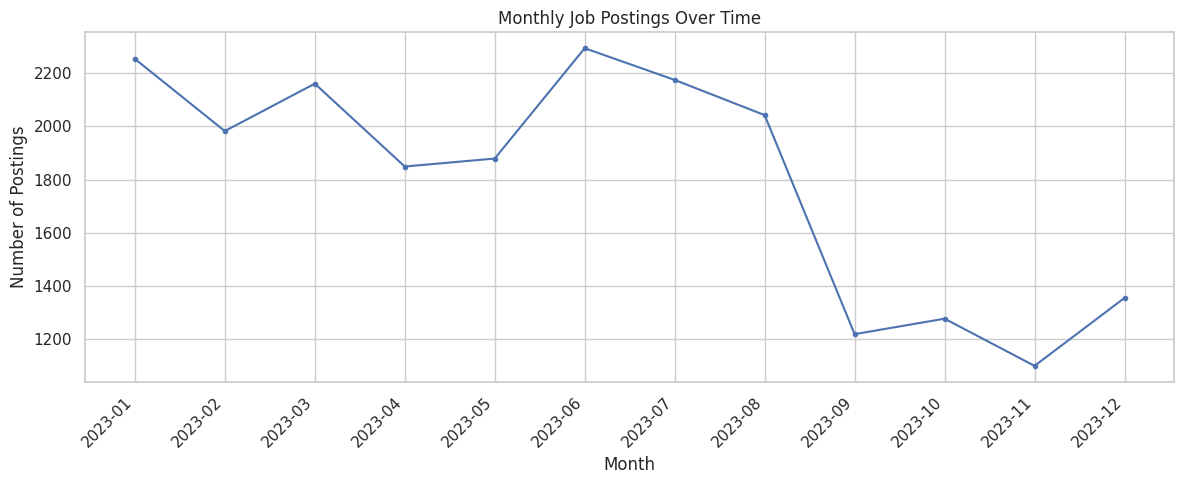

In [21]:
# fig6 — Monthly job postings over time ────────────────────────
monthly = (df.assign(ym=df['job_posted_date'].dt.to_period('M'))
             .groupby('ym').size()
             .reset_index(name='postings'))
monthly['ym_str'] = monthly['ym'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['ym_str'], monthly['postings'], marker='o', markersize=3)
ax.set_title('Monthly Job Postings Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Postings')
step = max(1, len(monthly) // 12)
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(monthly['ym_str'].iloc[::step], rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES / 'fig6_postings_over_time.png', dpi=120)
plt.show()

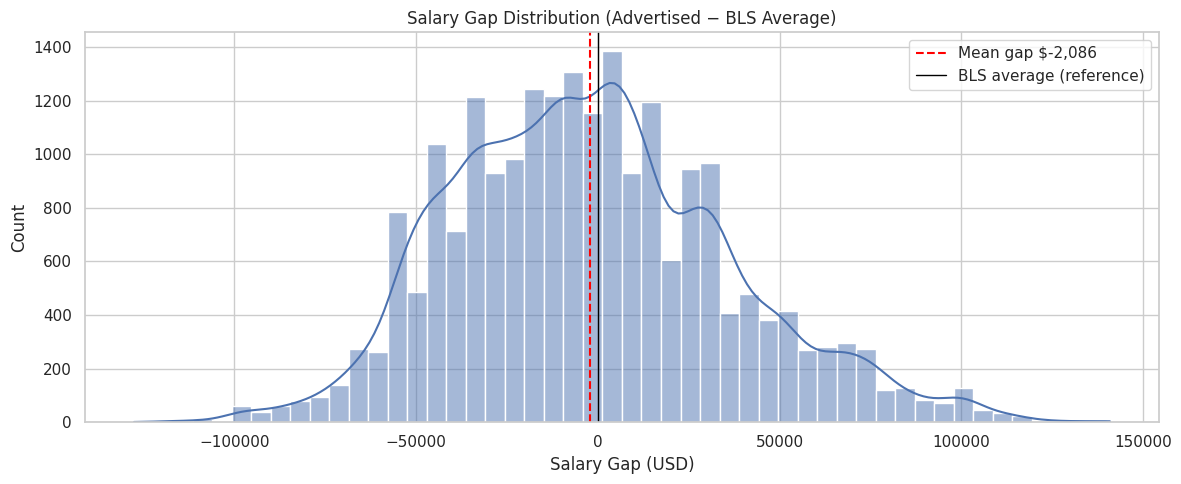

In [22]:
# fig7 — Salary gap distribution ───────────────────────────────
gap = df['salary_gap'].dropna()

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(gap, bins=50, kde=True, ax=ax)
ax.axvline(gap.mean(), color='red', linestyle='--',
           label=f"Mean gap ${gap.mean():,.0f}")
ax.axvline(0, color='black', linewidth=1,
           label='BLS average (reference)')
ax.set_title('Salary Gap Distribution (Advertised − BLS Average)')
ax.set_xlabel('Salary Gap (USD)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'fig7_salary_gap_distribution.png', dpi=120)
plt.show()

In [23]:
# Summary stats by role ────────────────────────────────────────
summary = (df.groupby('job_title_short')['salary_year_avg']
             .agg(['mean', 'median', 'std', 'min', 'max'])
             .round(0)
             .sort_values('median', ascending=False))
print('Summary statistics by role:')
display(summary)
n_figs = len(list(FIGURES.glob('*.png')))
print(f'Section 4 complete — {n_figs} figures saved to {FIGURES}/')

Summary statistics by role:


,mean,median,std,min,max
job_title_short,,,,,
Senior Data Scientist,147807.0,153147.0,35973.0,45000.0,240000.0
Senior Data Engineer,143070.0,147500.0,31786.0,35000.0,240000.0
Data Engineer,127005.0,125000.0,35624.0,15000.0,240000.0
Data Scientist,130562.0,125000.0,41448.0,27000.0,240000.0
Senior Data Analyst,112595.0,111175.0,28776.0,30000.0,240000.0
Machine Learning Engineer,123458.0,104668.0,49242.0,30000.0,240000.0
Software Engineer,109616.0,98496.0,44947.0,28000.0,240000.0
Data Analyst,93216.0,90000.0,31265.0,25000.0,240000.0
Cloud Engineer,108632.0,89550.0,46187.0,42000.0,221844.0


Section 4 complete — 7 figures saved to /app/figures/


## 5. Hypothesis Tests

In [24]:
df = pd.read_parquet(DATA_PROCESSED / 'jobs_enriched.parquet')
hyp_results = {}
print(f'Loaded {len(df):,} rows for hypothesis testing')

Loaded 21,587 rows for hypothesis testing


In [25]:
# H1 — Remote vs on-site salary (Mann-Whitney U) ───────────────
remote = df[df['job_work_from_home'] == True]['salary_year_avg']
onsite = df[df['job_work_from_home'] == False]['salary_year_avg']
u1, p1 = stats.mannwhitneyu(remote, onsite, alternative='two-sided')

print('H1 — Remote vs On-site salary')
print(f'  Remote median:  ${remote.median():,.0f}  (n={len(remote):,})')
print(f'  On-site median: ${onsite.median():,.0f}  (n={len(onsite):,})')
print(f'  U={u1:.0f},  p={p1:.4f}')
conclusion1 = 'Remote jobs pay significantly more (p<0.05).' if p1 < 0.05 else 'No significant salary difference between remote and on-site (p≥0.05).'
print(f'  Conclusion: {conclusion1}')

hyp_results['H1_remote_vs_onsite'] = {
    'remote_median': float(remote.median()),
    'onsite_median': float(onsite.median()),
    'u_statistic': float(u1), 'p_value': float(p1),
    'significant': bool(p1 < 0.05), 'conclusion': conclusion1,
}

H1 — Remote vs On-site salary
  Remote median:  $127,500  (n=3,219)
  On-site median: $115,000  (n=18,368)
  U=33880009,  p=0.0000
  Conclusion: Remote jobs pay significantly more (p<0.05).


In [26]:
# H2 — Python skill premium (Mann-Whitney U) ──────────────────
has_py = df[df['skills_list'].apply(lambda x: 'python' in x)]['salary_year_avg']
no_py  = df[df['skills_list'].apply(lambda x: 'python' not in x)]['salary_year_avg']
u2, p2 = stats.mannwhitneyu(has_py, no_py, alternative='two-sided')

print('H2 — Python skill premium')
print(f'  With Python:    ${has_py.median():,.0f}  (n={len(has_py):,})')
print(f'  Without Python: ${no_py.median():,.0f}  (n={len(no_py):,})')
print(f'  U={u2:.0f},  p={p2:.4f}')
conclusion2 = 'Python skill is linked to significantly higher salaries (p<0.05).' if p2 < 0.05 else 'No significant Python salary premium (p≥0.05).'
print(f'  Conclusion: {conclusion2}')

hyp_results['H2_python_premium'] = {
    'with_python_median': float(has_py.median()),
    'without_python_median': float(no_py.median()),
    'u_statistic': float(u2), 'p_value': float(p2),
    'significant': bool(p2 < 0.05), 'conclusion': conclusion2,
}

H2 — Python skill premium
  With Python:    $125,000  (n=12,585)
  Without Python: $100,275  (n=9,002)
  U=74366850,  p=0.0000
  Conclusion: Python skill is linked to significantly higher salaries (p<0.05).


In [27]:
# H3 — Advertised salary vs BLS average (one-sample t-test) ───
gap = df['salary_gap'].dropna()
t3, p3 = stats.ttest_1samp(gap, popmean=0)

print('H3 — Advertised salary vs BLS average  (H0: mean gap = 0)')
print(f'  Mean gap:  ${gap.mean():,.0f}')
print(f'  t={t3:.4f},  p={p3:.4f}')
conclusion3 = 'Advertised salaries differ significantly from BLS averages (p<0.05).' if p3 < 0.05 else 'No significant difference from BLS averages (p≥0.05).'
print(f'  Conclusion: {conclusion3}')

hyp_results['H3_advertised_vs_bls'] = {
    'mean_salary_gap': float(gap.mean()),
    't_statistic': float(t3), 'p_value': float(p3),
    'significant': bool(p3 < 0.05), 'conclusion': conclusion3,
}

H3 — Advertised salary vs BLS average  (H0: mean gap = 0)
  Mean gap:  $-2,086
  t=-7.9978,  p=0.0000
  Conclusion: Advertised salaries differ significantly from BLS averages (p<0.05).


In [28]:
# H4 — Salary across seniority levels (Kruskal-Wallis) ────────
junior = df[df['seniority'] == 'Junior']['salary_year_avg']
mid    = df[df['seniority'] == 'Mid']['salary_year_avg']
senior = df[df['seniority'] == 'Senior']['salary_year_avg']
h4, p4 = stats.kruskal(junior, mid, senior)

print('H4 — Salary across seniority levels')
print(f'  Junior median:  ${junior.median():,.0f}  (n={len(junior):,})')
print(f'  Mid median:     ${mid.median():,.0f}  (n={len(mid):,})')
print(f'  Senior median:  ${senior.median():,.0f}  (n={len(senior):,})')
print(f'  H={h4:.4f},  p={p4:.4f}')
conclusion4 = 'Salary differs significantly across seniority levels (p<0.05).' if p4 < 0.05 else 'No significant salary difference across seniority levels (p≥0.05).'
print(f'  Conclusion: {conclusion4}')

hyp_results['H4_seniority_levels'] = {
    'junior_median': float(junior.median()),
    'mid_median': float(mid.median()),
    'senior_median': float(senior.median()),
    'h_statistic': float(h4), 'p_value': float(p4),
    'significant': bool(p4 < 0.05), 'conclusion': conclusion4,
}

H4 — Salary across seniority levels
  Junior median:  $70,000  (n=466)
  Mid median:     $109,159  (n=14,359)
  Senior median:  $140,000  (n=6,762)
  H=2519.7120,  p=0.0000
  Conclusion: Salary differs significantly across seniority levels (p<0.05).


In [29]:
# Save results ─────────────────────────────────────────────────
out_path = RESULTS / 'hypothesis_results.json'
with open(out_path, 'w') as f:
    json.dump(hyp_results, f, indent=2)
print(f'Section 5 complete — results saved to {out_path}')

Section 5 complete — results saved to /app/results/hypothesis_results.json


## 6. Feature Engineering for ML

In [30]:
# ── Load enriched data ────────────────────────────────────────
from collections import Counter

df = pd.read_parquet(DATA_PROCESSED / 'jobs_enriched.parquet')
df['skills_list'] = df['skills_list'].apply(lambda x: list(x) if hasattr(x, '__iter__') and not isinstance(x, str) else [])
print(f'Loaded {len(df):,} rows for feature engineering')

Loaded 21,587 rows for feature engineering


In [31]:
# ── Binary skill features (top 20) ───────────────────────────
all_skills = [s for row in df['skills_list'] for s in row]
TOP_SKILLS = [s for s, _ in Counter(all_skills).most_common(20)]
for skill in TOP_SKILLS:
    df[f'skill_{skill}'] = df['skills_list'].apply(lambda x, sk=skill: int(sk in x))
print('Top 20 skills:', TOP_SKILLS)

Top 20 skills: ['sql', 'python', 'r', 'aws', 'tableau', 'spark', 'excel', 'azure', 'sas', 'java', 'power bi', 'snowflake', 'hadoop', 'scala', 'nosql', 'kafka', 'databricks', 'redshift', 'airflow', 'oracle']


In [32]:
# ── One-hot and binary encode ─────────────────────────────────
top_countries = df['job_country'].value_counts().head(20).index.tolist()
df['job_country_grp'] = (df['job_country']
                         .where(df['job_country'].isin(top_countries), 'Other')
                         .fillna('Other'))

for c in ['job_title_short', 'job_country_grp', 'seniority']:
    df[c] = df[c].fillna('Unknown')

df_ohe = pd.get_dummies(df[['job_title_short', 'job_country_grp', 'seniority']], dtype=int)
df_ohe['job_work_from_home']    = df['job_work_from_home'].fillna(False).astype(int)
df_ohe['job_no_degree_mention'] = df['job_no_degree_mention'].fillna(False).astype(int)

skill_cols = [f'skill_{s}' for s in TOP_SKILLS]
for _s in TOP_SKILLS:
    df_ohe[f'skill_{_s}'] = df[f'skill_{_s}'].values
df_ohe['salary_year_avg'] = df['salary_year_avg'].values

n_before = len(df_ohe)
df_ohe = df_ohe.dropna(subset=['salary_year_avg']).reset_index(drop=True)
print(f'Dropped {n_before - len(df_ohe):,} rows with null salary')
print(f'Feature matrix: {df_ohe.shape}')

Dropped 0 rows with null salary
Feature matrix: (21587, 57)


In [33]:
# ── Train/test split and save ─────────────────────────────────
from sklearn.model_selection import train_test_split

X_all = df_ohe.drop(columns=['salary_year_avg'])
y_all = df_ohe['salary_year_avg']
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

df_ohe.to_parquet(DATA_PROCESSED / 'features.parquet', index=False)
print(f'Section 6 complete — features.parquet saved ({X_all.shape[1]} features)')

Train: (17269, 56)  |  Test: (4318, 56)


Section 6 complete — features.parquet saved (56 features)


## 7. Salary Prediction Models

In [34]:
# ── Load features ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

df_feat = pd.read_parquet(DATA_PROCESSED / 'features.parquet')
X_all   = df_feat.drop(columns=['salary_year_avg'])
y_all   = df_feat['salary_year_avg']
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (17269, 56)  |  Test: (4318, 56)


In [35]:
# ── Train and evaluate three models ──────────────────────────
models_def = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}
trained_models = {}
preds_store    = {}
results        = {}

for name, mdl in models_def.items():
    mdl.fit(X_train, y_train)
    y_pred = mdl.predict(X_test)
    trained_models[name] = mdl
    preds_store[name]    = y_pred
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f'{name:25s}  RMSE={rmse:,.0f}  MAE={mae:,.0f}  R2={r2:.4f}')

df_results = pd.DataFrame(results).T.rename_axis('Model').reset_index()
df_results.to_csv(RESULTS / 'model_comparison.csv', index=False)
print('Saved model_comparison.csv')

Linear Regression          RMSE=34,415  MAE=27,426  R2=0.3063


Random Forest              RMSE=34,097  MAE=26,454  R2=0.3190
XGBoost                    RMSE=33,522  MAE=26,256  R2=0.3418
Saved model_comparison.csv


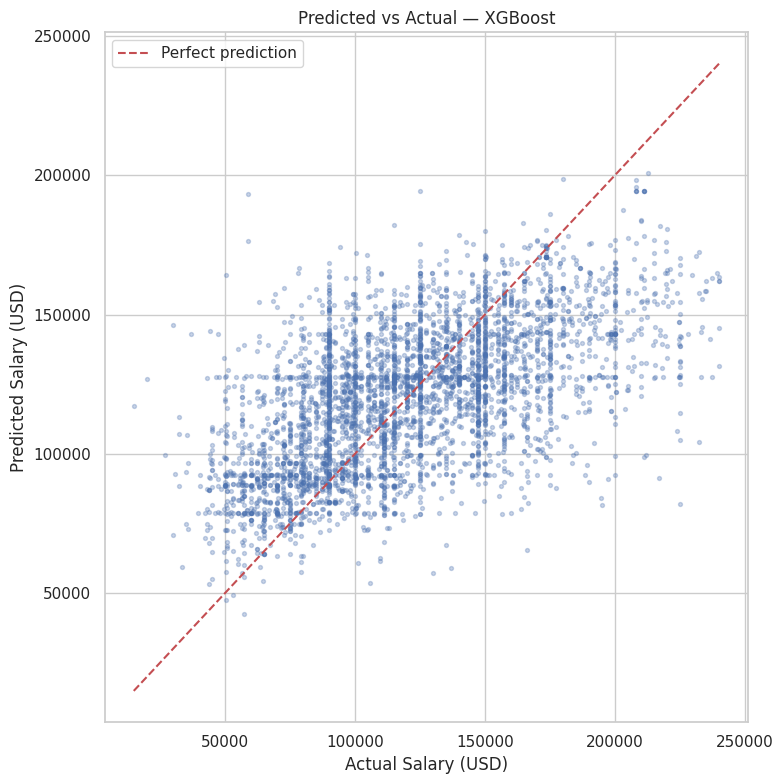

Section 7 complete — best model: XGBoost


In [36]:
# ── fig8 — Predicted vs actual (best model) ──────────────────
best_name   = df_results.sort_values('R2', ascending=False).iloc[0]['Model']
y_pred_best = preds_store[best_name]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_best, alpha=0.3, s=8)
lo, hi = float(y_test.min()), float(y_test.max())
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Salary (USD)')
ax.set_ylabel('Predicted Salary (USD)')
ax.set_title(f'Predicted vs Actual — {best_name}')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'fig8_pred_vs_actual.png', dpi=120)
plt.show()
print(f'Section 7 complete — best model: {best_name}')